In [4]:
#Question 5.2
import numpy as np
name=input('Enter document name: ')
x, y=np.loadtxt(name, unpack=True)
print('Min x =', np.min(x))
print('Max x =', np.max(x))
print('Mean x =', np.mean(x))

print('Min y =', np.min(y))
print('Max y =', np.max(y))
print('Mean y =', np.mean(y))

ym=np.median(y)
y2=(y-ym)**2
print(f'The new array y2 = {y2}')

Enter document name: SQ5_2.txt
Min x = 1.0
Max x = 9.0
Mean x = 4.25
Min y = 0.9
Max y = 8.3
Mean y = 4.630000000000001
The new array y2 = [ 0.0625  0.3025  3.8025  0.1225  8.1225  0.0625  0.0625 12.6025 10.5625
 14.8225]


In [2]:
#Question 5.6
import numpy as np
a = np.array([1, 2, 3])
b = np.array([4, 5, 6])
print(np.concatenate((a, b)))
print('This results in one long array consisting of both a, b')

aa = np.array([[1, 2], [3, 4]])
bb = np.array([[5, 6], [7, 8]])
print('The difference is that a and b are vectors (3x1), and aa and bb are (2x2) matrices')
print(np.concatenate((aa, bb)))
print('This yields a new matric of (4x2)')
print(np.concatenate((aa, bb), axis=0))
print('This is the same')
print(np.concatenate((aa, bb), axis=1))
print('This adds it to the right of the matrix becoming a (2x4) matrix')

[1 2 3 4 5 6]
This results in one long array consisting of both a, b
The difference is that a and b are vectors (3x1), and aa and bb are (2x2) matrices
[[1 2]
 [3 4]
 [5 6]
 [7 8]]
This yields a new matric of (4x2)
[[1 2]
 [3 4]
 [5 6]
 [7 8]]
This is the same
[[1 2 5 6]
 [3 4 7 8]]
This adds it to the right of the matrix becoming a (2x4) matrix


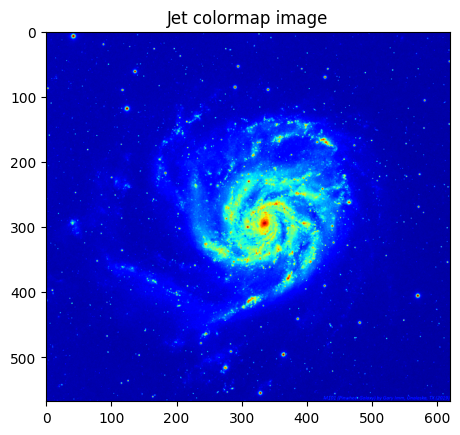

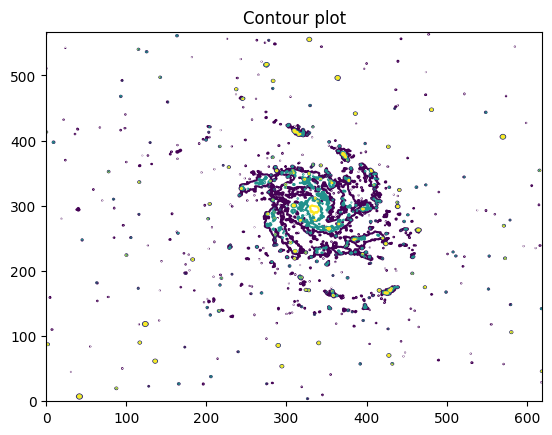

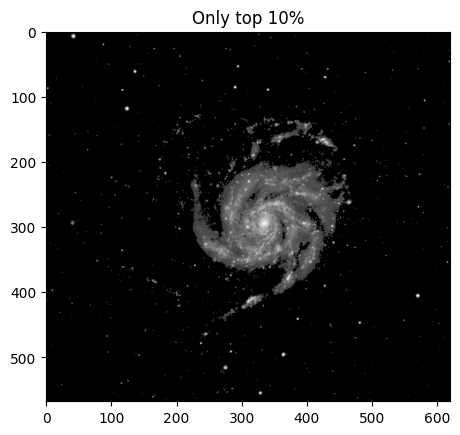

In [15]:
#Question 5.9
import imageio.v2 as imageio
import matplotlib.pyplot as plt
import numpy as np

image = imageio.imread('m101BW.jpg')
plt.figure()
plt.imshow(image, cmap='jet')
plt.title('Jet colormap image')

plt.figure()
plt.contour(image, levels=[100, 150, 200])
plt.title('Contour plot')
Limit = np.percentile(image, 90)
NewImage = np.where(image > Limit, image, 0)
plt.figure()
plt.imshow(NewImage, cmap='gray')
plt.title('Only top 10%')

plt.show()

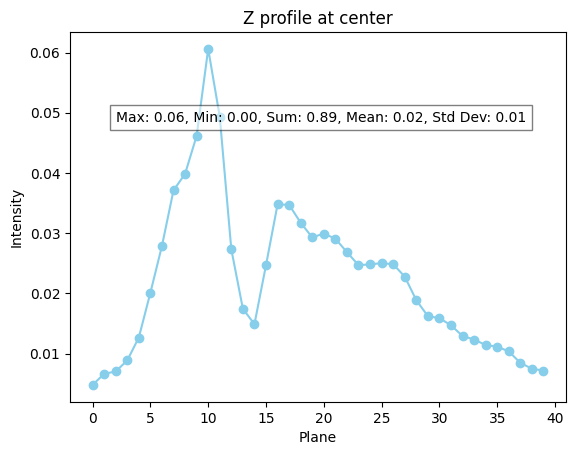

In [3]:
#Question 5.10
import numpy as np
import matplotlib.pyplot as plt

Stuff = np.loadtxt('ngc6946.txt')
Cubie = Stuff.reshape(40, 50, 70)
Z = Cubie[:, 25, 35]
Pmax = np.max(Z)
Pmin = np.min(Z)
Psum = np.sum(Z)
Pmean = np.mean(Z)
Pstd = np.std(Z)

plt.figure()
plt.plot(Z, color='skyblue', marker='o')
plt.title('Z profile at center')
plt.xlabel('Plane')
plt.ylabel('Intensity')
stats_text = (f"Max: {Pmax:.2f}, Min: {Pmin:.2f}, Sum: {Psum:.2f}, Mean: {Pmean:.2f}, Std Dev: {Pstd:.2f}")  
plt.text(2, Pmax*0.8, stats_text, bbox=dict(facecolor='white', alpha=0.5))
plt.show()

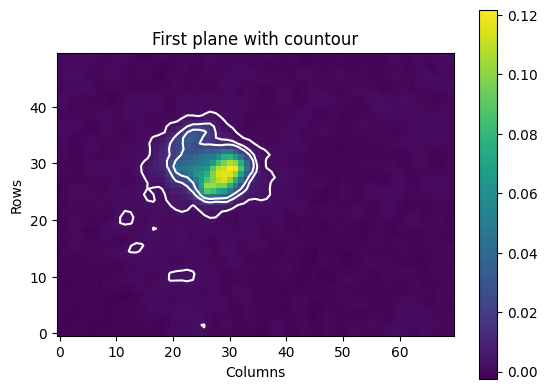

In [18]:
#Question 5.11
import numpy as np
import matplotlib.pyplot as plt
Stuff = np.loadtxt('ngc6946.txt')
Cubie = Stuff.reshape(40, 50, 70)
P1 = Cubie[10, -1, -1]

m= np.mean(P1)
s= np.std(P1)
levels=[m, m+s, m+2*s]
plt.figure()
plt.imshow(P1, cmap='viridis', origin='lower')
plt.colorbar()
plt.contour(P1, levels=levels, colors='white', origin='lower')
plt.title('First plane with countour')
plt.xlabel('Columns')
plt.ylabel('Rows')
plt.show()

In [24]:
#Question 5.12
import scipy.constants
class Galaxy:
    caH_0 = 3968.5
    c = scipy.constants.c / 1000 #for km/s instead of m/s
    def __init__(self, name, calciumHline=caH_0):
        self.name = name
        self.caH = calciumHline
    def redshift(self):        
        z = (self.caH - self.caH_0)/self.caH
        return z
    def velocity(self):
        return self.redshift()*self.c
#andromeda as an example: CalciumHline provided by chatgpt
Galax=Galaxy('Andromeda', calciumHline=3964.5)
print(f'Galaxy: {Galax.name}')
print(f'Velocity: {Galax.velocity()} km/s')

Galaxy: Andromeda
Velocity: -302.4769408500441 km/s


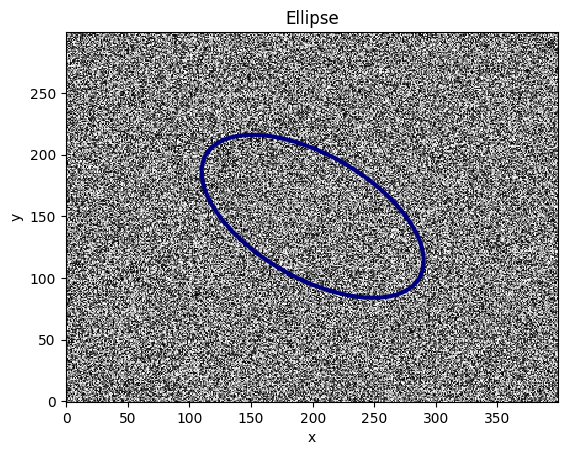

In [9]:
#Question 5.13
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

Nx = 400
Ny = 300
Wagwan = np.random.random((Ny, Nx))

class AstroEllipse(Ellipse):
    def __init__(self, xc, yc, semi_major, semi_minor, position_angle, **kwargs):
        assert semi_major >= semi_minor
        XY = (xc, yc)
        angle_mpl = 90- position_angle
        height = 2.0 * semi_major
        width = 2.0 * semi_minor
        super().__init__(XY, width, height, angle=angle_mpl, **kwargs)

fig, ax = plt.subplots()

plt.imshow(Wagwan, interpolation='none', origin='lower', cmap='gray')
ellipse = AstroEllipse(200, 150, 100, 50, 30, edgecolor='navy', facecolor='none', lw=3)
ax.add_patch(ellipse)
plt.title('Ellipse')
plt.xlabel('x')
plt.ylabel('y')

plt.show()